# Cosmetics Catalog Analysis and Data Quality

Analyzed a 931-product cosmetics catalog using Python and pandas, exploring brand coverage, product types, pricing and ratings. Improved the analysis by preserving missing values and separating currencies. Identified substantial rating and currency gaps that prevent a reliable price–rating comparison, turning the project into a transparent, evidence-based catalog analysis rather than making unsupported market claims.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Audited missingness, duplicates, invalid prices and ratings; preserved missing values as missing. Compared brand/product coverage and summarized prices within currency. Kept product type distinct from subcategory and separated catalog counts from sales or market share.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,value
dataset,Local output.csv.zip cosmetics catalog
input_sha256,7e97065bb6b139b9ac23af88441fb8c1cba68e320aeec2...
source_rows,931
clean_rows,931
exact_duplicates_removed,0
invalid_prices,0
invalid_ratings,0
missing_rating_fraction,0.634801
missing_currency_fraction,0.604726
zero_price_rows,40


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.12.2',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'scipy': '1.18.1',
 'seed': 42}

Data fingerprint: 7e97065bb6b139b9ac23af88441fb8c1cba68e320aeec2f6a0d7ebaa573bba5e


## Figures

catalog_composition.png


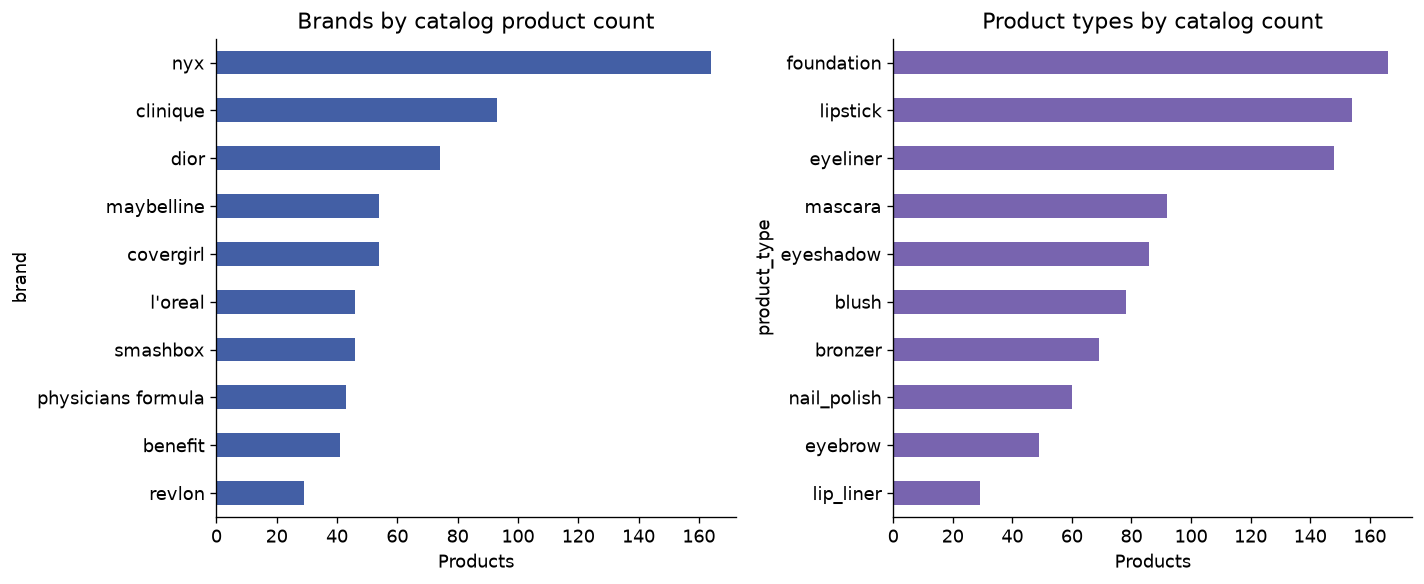

missingness.png


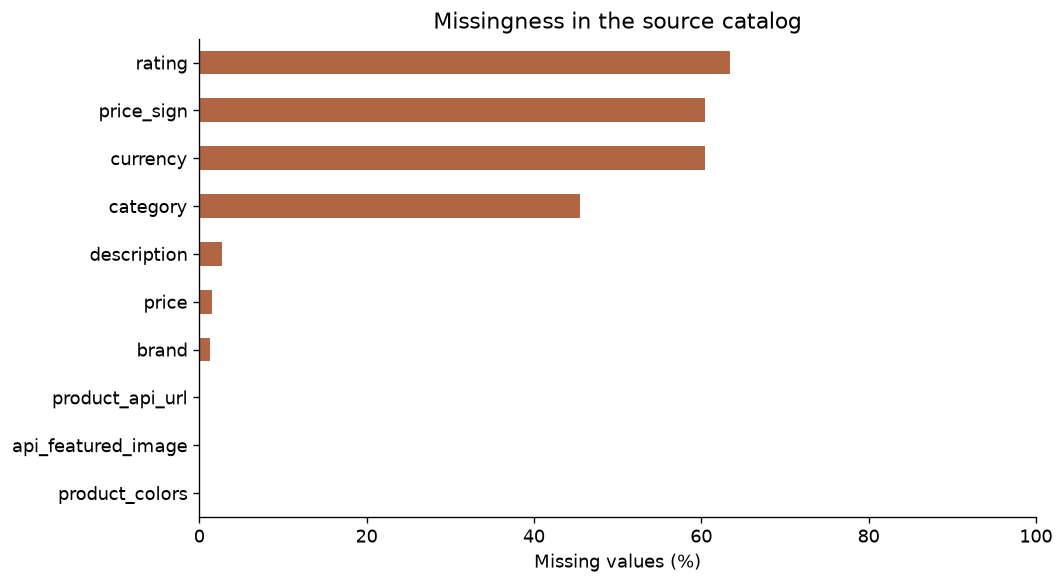

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

This catalog contains 931 products. Ratings are missing for 63.48% and currency for 60.47%; all 340 rated rows lack a currency. None of the rows with known currency has a rating, so a currency-controlled price–rating correlation cannot be estimated. Zero prices may represent unavailable prices. The privately saved Colab/Kaggle final version has not been inspected.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python analyze.py --data output.csv --out results'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)